<a href="https://colab.research.google.com/github/Joseph-Garvey/cues-ai-hackathon/blob/main/data_analysis/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yes/no data analysis

In [ ]:
# YES/NO DATA ANALYSIS
self_results_dishonest = ["yes", "yes", "yes", "no"]


self_honest_correct = results_dishonest.count("yes")
self_honest_incorrect = results_dishonest.count("no")
self_honest_accuracy = self_honest_correct / (self_honest_correct + self_honest_incorrect)

self_dishonest_correct = results_dishonest.count("no")
self_dishonest_incorrect = results_dishonest.count("yes")
self_dishonest_accuracy = self_dishonest_correct / (self_dishonest_correct + self_dishonest_incorrect)

self_accuracy = (self_honest_accuracy + self_dishonest_accuracy) / 2

peer_honest_correct = results_dishonest.count("yes")
peer_honest_incorrect = results_dishonest.count("no")
peer_honest_accuracy = peer_honest_correct / (peer_honest_correct + peer_honest_incorrect)

peer_dishonest_correct = results_dishonest.count("no")
peer_dishonest_incorrect = results_dishonest.count("yes")
peer_dishonest_accuracy = self_dishonest_accuracy = self_dishonest_correct / (self_dishonest_correct + self_dishonest_incorrect)

peer_accuracy = (peer_honest_accuracy + peer_dishonest_accuracy) / 2


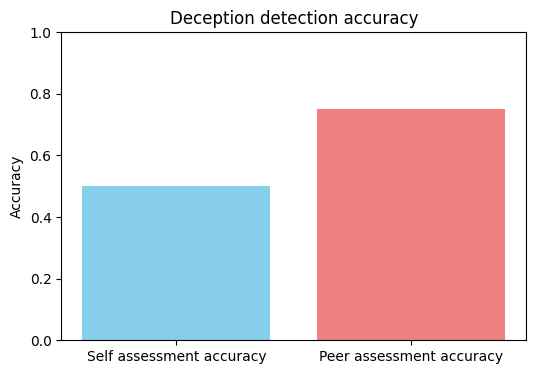

In [ ]:
# YES/NO BAR CHART
import matplotlib.pyplot as plt


peer_accuracy = 0.75
self_accuracy = 0.5

values = [self_accuracy, peer_accuracy]
labels = ["Self assessment accuracy", "Peer assessment accuracy"]


# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Deception detection accuracy')
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'colour'

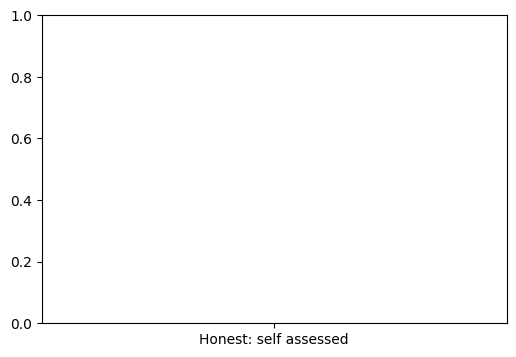

In [ ]:
# YES/NO DETAILED BAR CHART

import matplotlib.pyplot as plt


peer_accuracy = 0.75
self_accuracy = 0.5

values = [self_honest_accuracy, self_dishonest_accuracy, peer_honest_accuracy, peer_dishonest_accuracy]
labels = ["Honest: self assessed", "Dishonest: self assessed", "Honest: peer assessed", "Dishonest: peer assessed"]

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, colour=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Deception detection accuracy')
plt.show()

# 0 to 1 probability data analysis

define 'positive' = 'detected as being deceptive'

define 'negative' = 'detected as being truthful'

0 --> believes it is the truth

1 --> believes it is deceptive

## libraries

In [143]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os
from sklearn.metrics import auc

## load, extract data

In [ ]:
# DATA EXTRACTION
def extract_float(s):
    try:
        return float(s)
    except ValueError: # if direct conversion fails
        # This regex now more generally looks for a floating point number
        # anywhere in the string, including cases like '0.5</' where '0.5' is extracted.
        match = re.search(r'([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)', s)
        if match:
            return float(match.group(1))
        return None # if no float found

def clean_data(lists):
  clean_lists = []
  converted = []
  for list_item in lists:
    clean_list = [extract_float(item) for item in list_item]
    prop_converted = 1 - clean_list.count(None)/len(clean_list)
    converted.append(prop_converted)
    clean_list = [i for i in clean_list if i is not None]
    clean_lists.append(clean_list)
  print(f"proportion of data successfully loaded\n[self_honest, self_dishonest, peer_honest, peer_dishonest]\n{converted}")
  return clean_lists

In [ ]:
# READ, EXTRACT DATA
#to load directly from gdrive:
#save data to following filepath: /content/drive/MyDrive/Hackathon/Data_for_graphs/
#or change filepath
#or change code and load files locally

def data_from_drive():

  df_data_files = []
  filenames = []
  data_arrays = []

  drive.mount('/content/drive/', force_remount=True)
  print("\n\n")
  data_path = '/content/drive/MyDrive/Hackathon/Data_for_graphs/'
  # Ensure the directory exists before listing its contents
  if not os.path.exists(data_path):
      print(f"Warning: Directory not found: {data_path}")
      return [], [] # Return empty lists if directory doesn't exist

  for filename in os.listdir(data_path):
    if filename.endswith('.csv'): # Only process CSV files
      filenames.append(filename.replace(".csv", ""))
      df_data_file = pd.read_csv(data_path + filename)
      df_data_files.append(df_data_file)

      print(f"{filenames[-1]}: data loaded") # Use filenames[-1] for current file

      column_lists = {}

      for column in df_data_file.columns:
          column_lists[column] = df_data_file[column].tolist()

      self_honest = column_lists.get('honest_self', []) # Use .get with default empty list
      self_dishonest = column_lists.get('dishonest_self', [])
      peer_honest = column_lists.get('honest_peer', [])
      peer_dishonest = column_lists.get('dishonest_peer', []) # Corrected typo here
      data_arrays.append([self_honest, self_dishonest, peer_honest, peer_dishonest])
    else:
        print(f"Skipping non-CSV file: {filename}")

  return filenames, data_arrays # Move return statement outside the loop

## process data

In [153]:
# find true, false positive rate
def tpr_fpr(honest_assessment, dishonest_assessment, threshold):
  tpr = sum(1 for i in dishonest_assessment if i >= threshold) / len(dishonest_assessment)
  fpr = sum(1 for i in honest_assessment if i >= threshold) / len(honest_assessment)
  return tpr, fpr

# Helper function to plot ROC curve on a given axes, returns AUROC
def plot_roc_curve_on_ax(ax, honest_assessment, dishonest_assessment, title="Graph"):
  tpr_list = []
  fpr_list = []
  for i in np.linspace(0,1,50):
    tpr, fpr = tpr_fpr(honest_assessment, dishonest_assessment, i)
    tpr_list.append(tpr)
    fpr_list.append(fpr)

  area = -np.trapezoid(tpr_list, fpr_list)

  ax.plot(fpr_list, tpr_list, 'o-', clip_on=False, zorder=3, color='#324c55')  # Changed data points color

  # Shade the area under the curve
  ax.fill_between(fpr_list, tpr_list, color='#bed2d8', alpha=0.4, label=f'AUROC = {area:.3f}') # Changed fill color

  ax.set_title(f'{title}')
  ax.title.set_position([0.5, 1.5]) # Increased y position to 1.15
  ax.set_xlabel('False positive rate')
  ax.set_ylabel('True positive rate')
  ax.set_xlim(0, 1)
  ax.set_ylim(0, 1)

  # Add more gridlines
  ax.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.7)
  ax.minorticks_on()
  ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

  ax.legend()
  return area # Return AUROC value


## --> Open data from gdrive, print graphs <--

Mounted at /content/drive/



Claude Sonnet 4 (deceptive): data loaded
Claude Haiku 4.5 (deceptive): data loaded
Skipping non-CSV file: claude-haiku-4-5-20251001_honestytest.json
Claude Haiku 3 (deceptive): data loaded
Skipping non-CSV file: claude-3-haiku-20240307_honestytest.json
Claude Sonnet 4.5 (deceptive): data loaded
Skipping non-CSV file: claude-sonnet-4-5-20250929_honestytest.json
Claude Haiku 3.5 (deceptive): data loaded
Claude Opus 4.1 (deceptive): data loaded
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 0.9919137466307277, 0.9919137466307277]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Sonnet 4 (deceptive)_combined_assessments.png


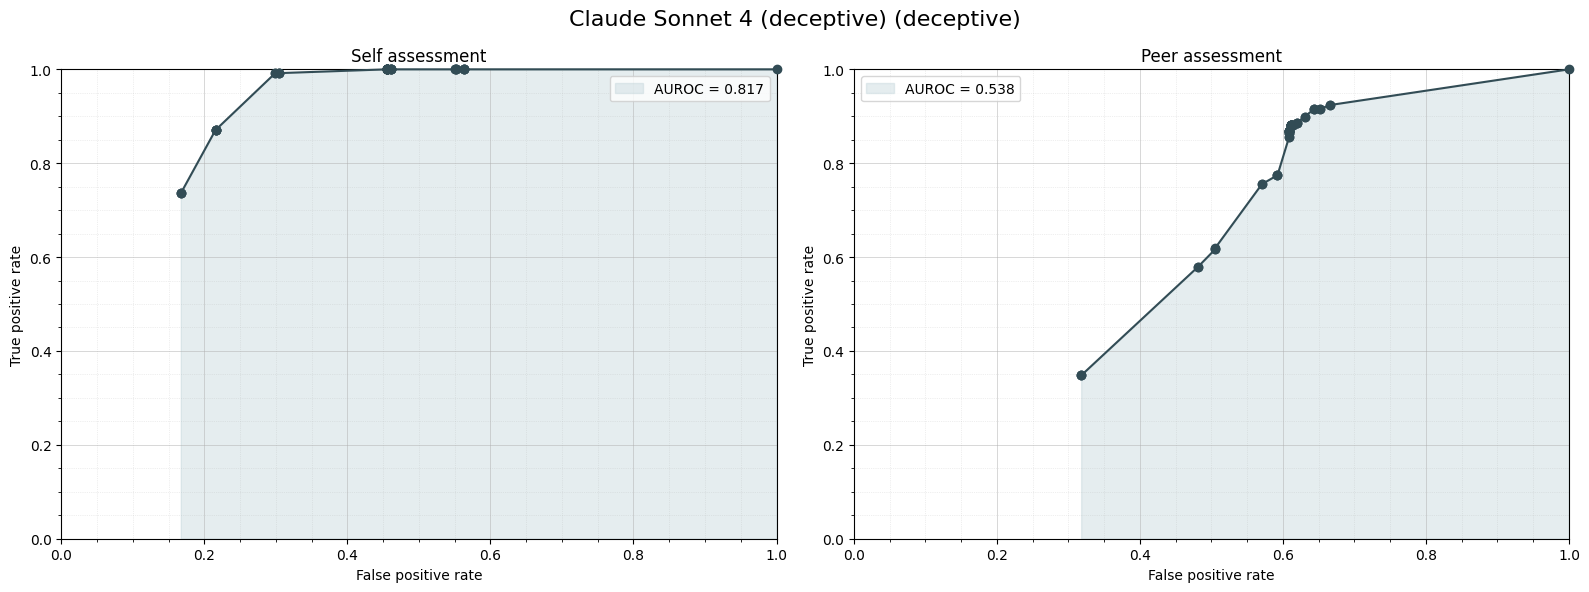

proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 0.9973045822102425, 0.9649595687331536, 0.9272237196765498]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Haiku 4.5 (deceptive)_combined_assessments.png


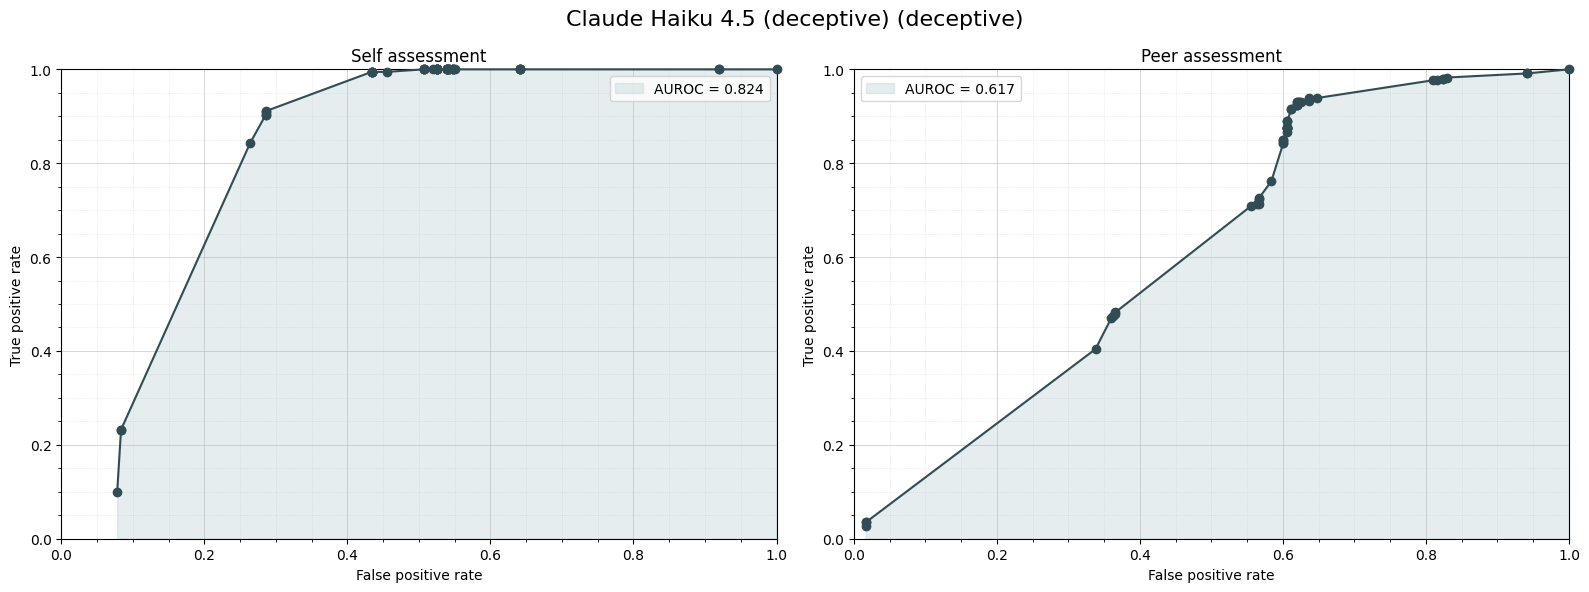

proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 1.0, 1.0]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Haiku 3 (deceptive)_combined_assessments.png


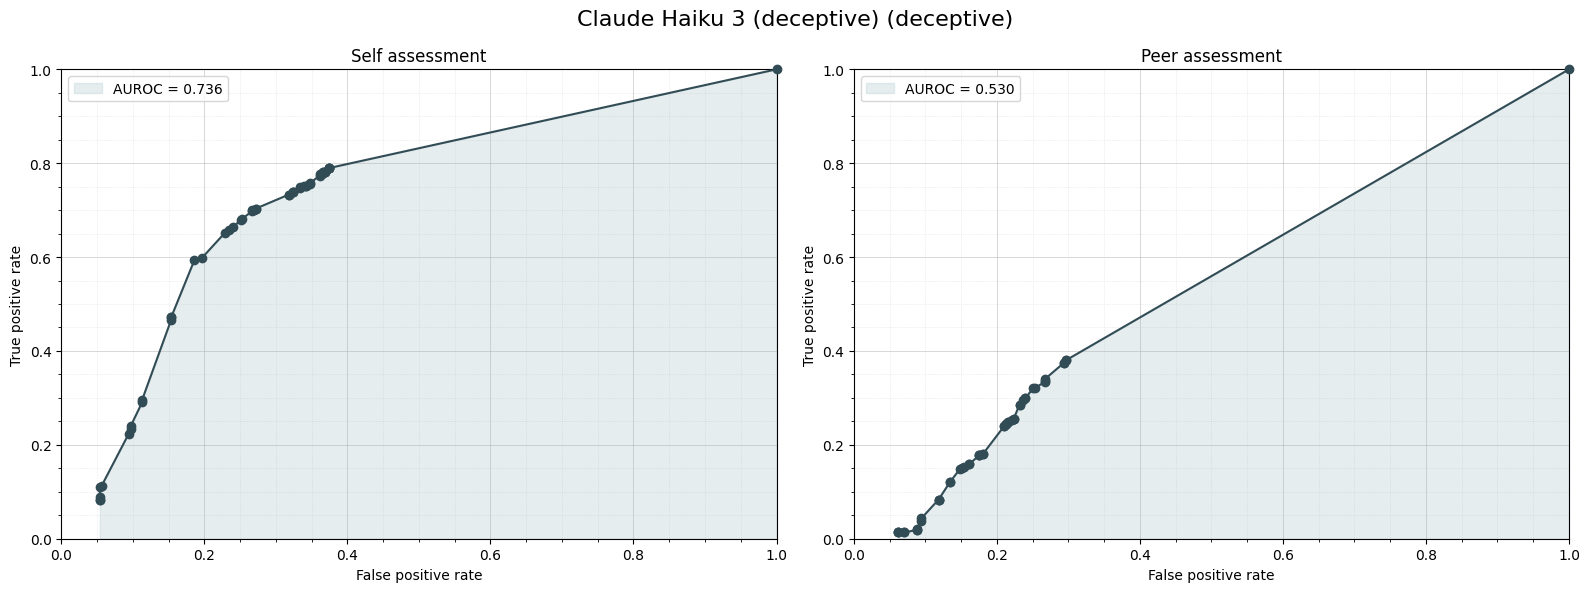

proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 1.0, 1.0]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Sonnet 4.5 (deceptive)_combined_assessments.png


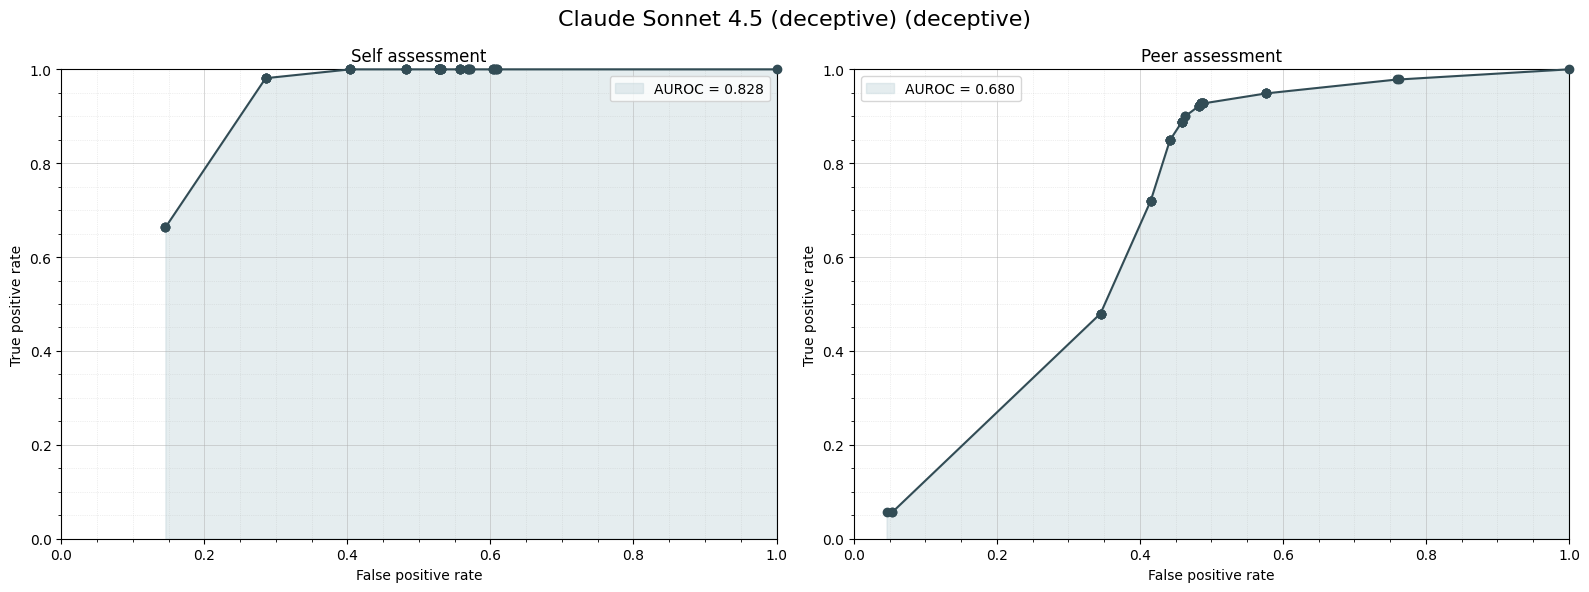

proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[0.9595687331536388, 0.9595687331536388, 1.0, 1.0]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Haiku 3.5 (deceptive)_combined_assessments.png


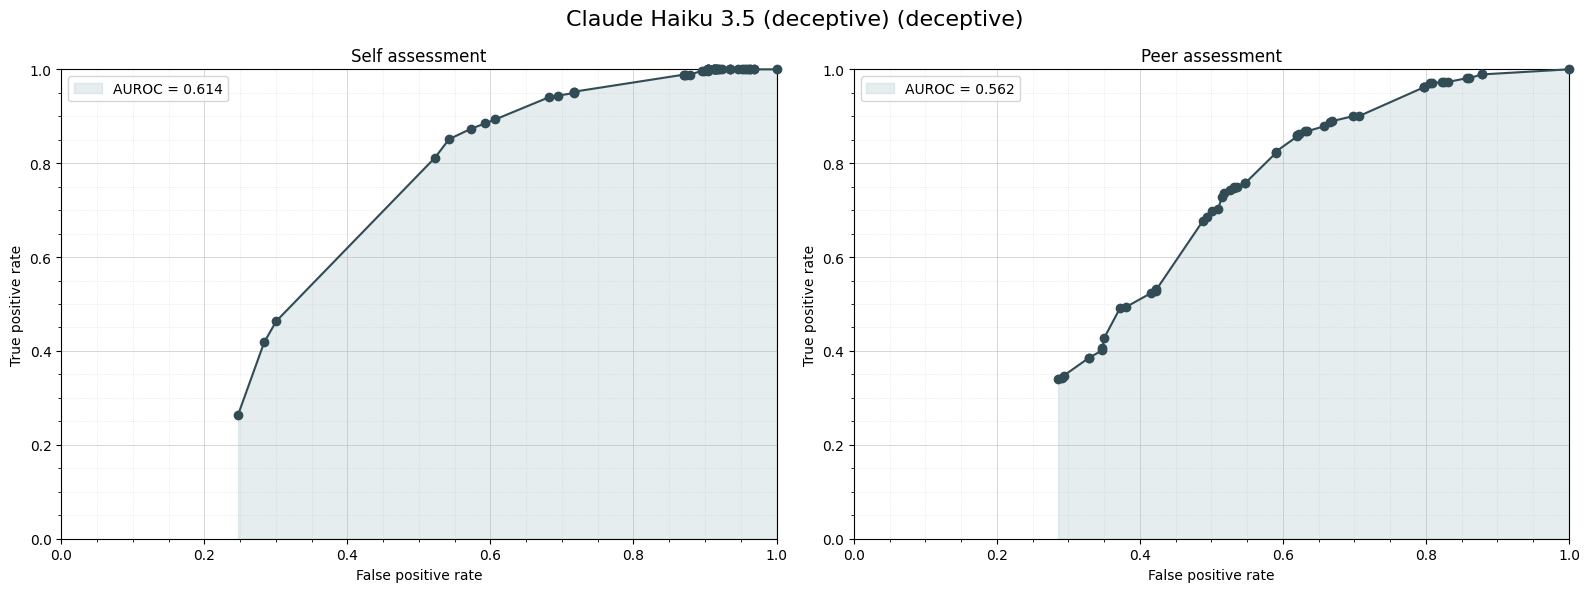

proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 0.967654986522911, 0.9784366576819407]
Combined graph saved to: /content/drive/MyDrive/Hackathon/data-20251116_114332/Claude Opus 4.1 (deceptive)_combined_assessments.png


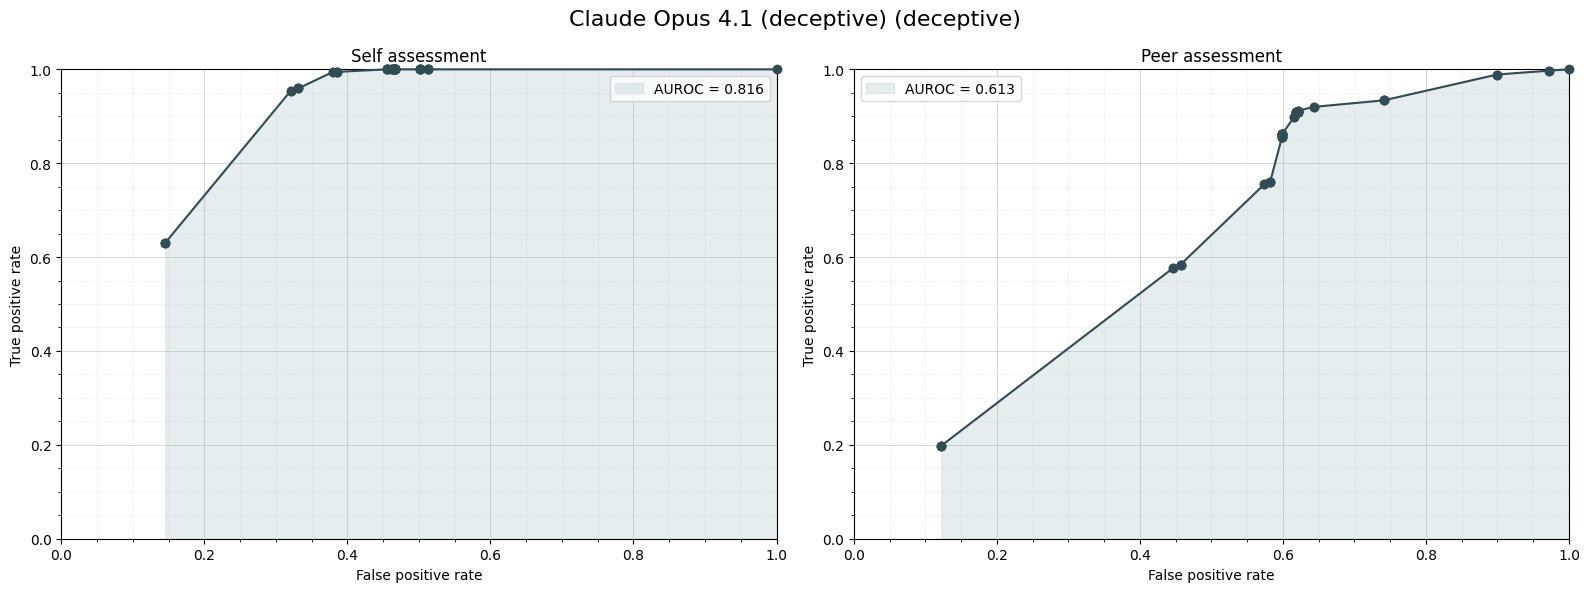

In [154]:
filenames, data_arrays = data_from_drive()

# Define the base save path in Google Drive
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
graph_save_base_path = f'/content/drive/MyDrive/Hackathon/data-{timestamp}/'

for i in range(len(filenames)):

  cleaned_data_for_current_file = clean_data(data_arrays[i]) # Renaming for clarity

  self_honest = cleaned_data_for_current_file[0]
  self_dishonest = cleaned_data_for_current_file[1]
  peer_honest = cleaned_data_for_current_file[2]
  peer_dishonest = cleaned_data_for_current_file[3]

  # Create a figure with two subplots side-by-side
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  # Set a shared super title for the entire figure
  fig.suptitle(f'{filenames[i]} (deceptive)', fontsize=16)
  fig.subplots_adjust(top=0.88) # Adjust top to make space for the suptitle and allow subplot titles to move higher

  # Plot Self assessment ROC curve on the first axes (ax1)
  if self_honest and self_dishonest:
      plot_roc_curve_on_ax(ax1, self_honest, self_dishonest, title="Self assessment")
      # Removed redundant ax1.set_title here, as it's set in plot_roc_curve_on_ax
  else:
      ax1.set_title("Self assessment (No data)") # Still need this if there's no data
      ax1.title.set_position([0.5, 1.5]) # Increased y position to 1.15 for no data title as well
      print(f"Cannot generate Self assessment ROC curve for {filenames[i]}: Insufficient numerical data.")

  # Plot Peer assessment ROC curve on the second axes (ax2)
  if peer_honest and peer_dishonest:
      plot_roc_curve_on_ax(ax2, peer_honest, peer_dishonest, title="Peer assessment")
      # Removed redundant ax2.set_title here, as it's set in plot_roc_curve_on_ax
  else:
      ax2.set_title("Peer assessment (No data)") # Still need this if there's no data
      ax2.title.set_position([0.5, 1.5]) # Increased y position to 1.15 for no data title as well
      print(f"Cannot generate Peer assessment ROC curve for {filenames[i]}: Insufficient numerical data.")

  plt.tight_layout() # Removed rect, relying on subplots_adjust for overall spacing

  # Save the combined figure
  combined_filename = f"{filenames[i]}_combined_assessments.png"
  os.makedirs(graph_save_base_path, exist_ok=True)
  plt.savefig(os.path.join(graph_save_base_path, combined_filename))
  print(f"Combined graph saved to: {os.path.join(graph_save_base_path, combined_filename)}")

  plt.show()
  plt.close(fig) # Close the figure to free up memory

## Initialize Combined Figure

### Subtask:
Create a matplotlib figure with two subplots. One subplot will display all self-assessment ROC curves, and the other will display all peer-assessment ROC curves.


proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 0.9919137466307277, 0.9919137466307277]
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 0.9973045822102425, 0.9649595687331536, 0.9272237196765498]
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 1.0, 1.0]
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 1.0, 1.0]
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[0.9595687331536388, 0.9595687331536388, 1.0, 1.0]
proportion of data successfully loaded
[self_honest, self_dishonest, peer_honest, peer_dishonest]
[1.0, 1.0, 0.967654986522911, 0.9784366576819407]
Combined ROC curves graph saved to: /content/drive/MyDrive/Hackathon/combined_roc_graphs/combined_roc_curves_20251116_115909.png


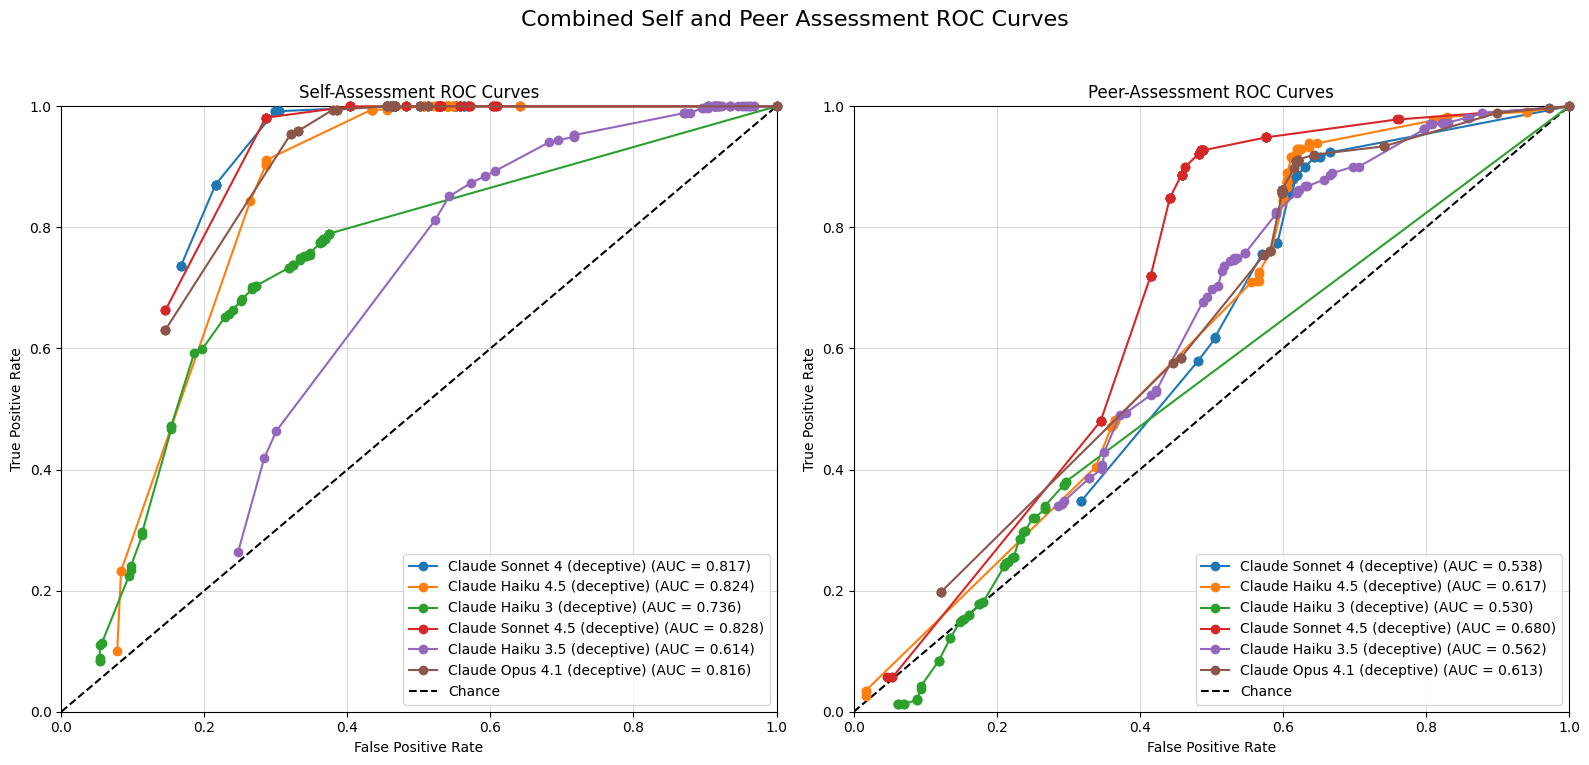

Combined AUC bar graph saved to: /content/drive/MyDrive/Hackathon/combined_bar_graphs/combined_auc_bar_graph_20251116_115910.png


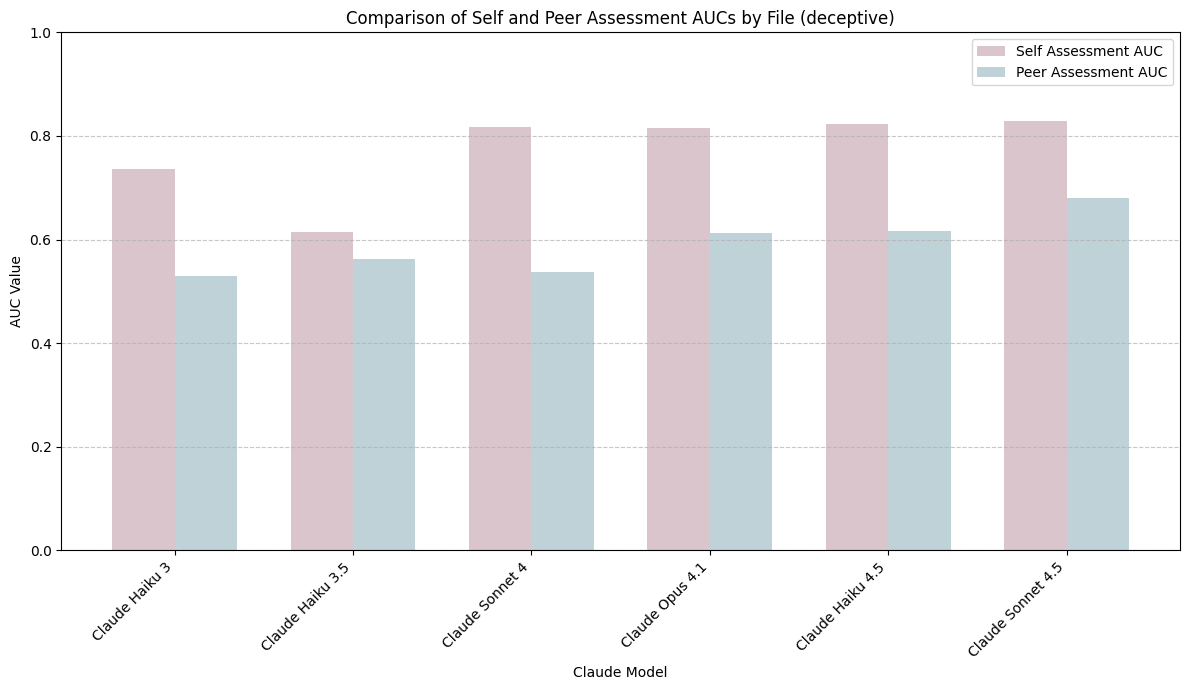

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from sklearn.metrics import auc
import re

# --- ROC Curve plotting setup ---
# Create a figure with two subplots side-by-side for ROC curves
fig_roc, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Data collection for bar chart ---
# Instead of separate lists, we'll store tuples to facilitate sorting
data_for_bar_chart = []
# --- End data collection setup ---

for i in range(len(filenames)):
    cleaned_data_for_current_file = clean_data(data_arrays[i])

    self_honest = cleaned_data_for_current_file[0]
    self_dishonest = cleaned_data_for_current_file[1]
    peer_honest = cleaned_data_for_current_file[2]
    peer_dishonest = cleaned_data_for_current_file[3]

    auc_self = 0.0 # Initialize to 0.0 for files with no data
    auc_peer = 0.0 # Initialize to 0.0 for files with no data

    # Calculate self-assessment AUC and plot ROC
    if self_honest and self_dishonest:
        tpr_list_self = []
        fpr_list_self = []
        for j in np.linspace(0, 1, 50):
            tpr, fpr = tpr_fpr(self_honest, self_dishonest, threshold=j)
            tpr_list_self.append(tpr)
            fpr_list_self.append(fpr)
        # Using sklearn.metrics.auc for robust calculation
        auc_self = auc(fpr_list_self, tpr_list_self)
        ax1.plot(fpr_list_self, tpr_list_self, 'o-', clip_on=False, zorder=3, label=f'{filenames[i]} (AUC = {auc_self:.3f})')
    else:
        print(f"Cannot generate Self assessment ROC curve for {filenames[i]}: Insufficient numerical data. AUC set to 0.")

    # Calculate peer-assessment AUC and plot ROC
    if peer_honest and peer_dishonest:
        tpr_list_peer = []
        fpr_list_peer = []
        for j in np.linspace(0, 1, 50):
            tpr, fpr = tpr_fpr(peer_honest, peer_dishonest, threshold=j)
            tpr_list_peer.append(tpr)
            fpr_list_peer.append(fpr)
        # Using sklearn.metrics.auc for robust calculation
        auc_peer = auc(fpr_list_peer, tpr_list_peer)
        ax2.plot(fpr_list_peer, tpr_list_peer, 'o-', clip_on=False, zorder=3, label=f'{filenames[i]} (AUC = {auc_peer:.3f})')
    else:
        print(f"Cannot generate Peer assessment ROC curve for {filenames[i]}: Insufficient numerical data. AUC set to 0.")

    # Extract numerical value from filename for sorting
    # This regex looks for the first sequence of digits, optionally followed by a dot and more digits
    match = re.search(r'(\d+\.?\d*)', filenames[i])
    numeric_prefix = float(match.group(1)) if match else 0.0 # Default to 0.0 if no number found

    # Collect data for the bar chart regardless of whether ROC was plotted
    data_for_bar_chart.append((numeric_prefix, filenames[i], auc_self, auc_peer))

# Add diagonal reference line (y=x) to both ROC subplots
ax1.plot([0, 1], [0, 1], 'k--', label='Chance')
ax2.plot([0, 1], [0, 1], 'k--', label='Chance')

# Set titles, labels, limits, and legends for the ROC subplots
ax1.set_title('Self-Assessment ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend(loc='lower right')
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.7)

ax2.set_title('Peer-Assessment ROC Curves')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend(loc='lower right')
ax2.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.7)

# Set a super title for the entire ROC figure and adjust layout
fig_roc.suptitle('Combined Self and Peer Assessment ROC Curves', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap

# Save the combined ROC figure to Google Drive
timestamp_roc = datetime.now().strftime("%Y%m%d_%H%M%S")
graph_save_base_path_roc = f'/content/drive/MyDrive/Hackathon/combined_roc_graphs/'
os.makedirs(graph_save_base_path_roc, exist_ok=True)
combined_filename_roc = f"combined_roc_curves_{timestamp_roc}.png"
plt.savefig(os.path.join(graph_save_base_path_roc, combined_filename_roc))
print(f"Combined ROC curves graph saved to: {os.path.join(graph_save_base_path_roc, combined_filename_roc)}")

# Display the combined ROC figure
plt.show()
plt.close(fig_roc) # Close the ROC figure to free up memory


# --- Bar Chart plotting ---

# Sort the collected data based on the numeric prefix
data_for_bar_chart.sort(key=lambda x: x[0])

# Unpack the sorted data back into separate lists for plotting
all_filenames_for_bar_chart = [item[1] for item in data_for_bar_chart]
self_auc_values_for_bar_chart = [item[2] for item in data_for_bar_chart]
peer_auc_values_for_bar_chart = [item[3] for item in data_for_bar_chart]

# Extract text in brackets for the title (from the first filename with brackets found)
bracketed_text_for_title = ""
for fname in all_filenames_for_bar_chart:
    match = re.search(r'\((.*?)\)', fname)
    if match:
        bracketed_text_for_title = f" ({match.group(1)})";
        break

# Prepare x-tick labels by removing bracketed text
x_tick_labels = [re.sub(r'\s*\(.*?\)', '', fname) for fname in all_filenames_for_bar_chart]

fig_bar, ax_bar = plt.subplots(figsize=(12, 7))

bar_width = 0.35
index = np.arange(len(x_tick_labels))

bar1 = ax_bar.bar(index, self_auc_values_for_bar_chart, bar_width, label='Self Assessment AUC', color='#d9c5cb')
bar2 = ax_bar.bar(index + bar_width, peer_auc_values_for_bar_chart, bar_width, label='Peer Assessment AUC', color='#bed2d8')

ax_bar.set_xlabel('Anthropic Model')
ax_bar.set_ylabel('AUC Value')
ax_bar.set_title(f'Comparison of Self and Peer Assessment AUCs by File{bracketed_text_for_title}')
ax_bar.set_xticks(index + bar_width / 2)
ax_bar.set_xticklabels(x_tick_labels, rotation=45, ha='right')
ax_bar.set_ylim(0, 1) # AUC values are between 0 and 1
ax_bar.legend()
ax_bar.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the bar graph to Google Drive
timestamp_bar = datetime.now().strftime("%Y%m%d_%H%M%S")
graph_save_base_path_bar = f'/content/drive/MyDrive/Hackathon/combined_bar_graphs/'
os.makedirs(graph_save_base_path_bar, exist_ok=True)
combined_filename_bar = f"combined_auc_bar_graph_{timestamp_bar}.png"
plt.savefig(os.path.join(graph_save_base_path_bar, combined_filename_bar))
print(f"Combined AUC bar graph saved to: {os.path.join(graph_save_base_path_bar, combined_filename_bar)}")

# Display the combined figure
plt.show()

# Close the figure to free up memory
plt.close(fig_bar)